## Etapa 0 - Entendimento de negócio

**A pergunta que queremos desenvolver com o desenvolvimento do projeto é:**

- É possível prever, no momento da realização do pedido, se uma entrega será realizada após a data estimada?

**Como hipótese inicial temos:**

- Características do pedido, do cliente, do vendedor, do produto e da logística estão associadas à probabilidade de atraso na entrega.

**Objetivo do projeto:**

- Construir e avaliar os resultados de um modelo preditivo capaz de classificar pedidos como:
    - 0: entregue no prazo;
    - 1: entregue com atraso.

**Fonte de dados:**

- Utilizaremos o conjunto de dados [Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce), que contém cerca de 100 mil pedidos realizados entre 2016 e 2018 e reúne informações de pedidos, clientes, produtos, vendedores, pagamentos e avaliações.

```md
                    OLIST
                      │
         ┌────────────┼────────────┐
         ▼            ▼            ▼
       orders       items       customers
         │            │            │
         │        products         │
         │            │            │
         │        sellers          │
         │            │            │
         └────────────┼────────────┘
                      ▼
              DATASET ANALÍTICO
                  1 linha =
                  1 pedido
```

- Devido a extensão do conjunto de dados, optamos por utilizar uma versão reduzida, dessa forma, seguiremos com os seguintes datasets e variáveis:

    1. olist_orders_dataset.csv, para:
    - datas;
    - status;
    - target.

    2. olist_customers_dataset.csv, para:
    - estado;
    - cidade;
    - localização.

    3. olist_order_items_dataset.csv, para:
    - preço;
    - frete;
    - quantidade de itens;
    - seller;
    - produto.

    4. olist_products_dataset.csv, para:
    - categoria;
    - peso;
    - dimensões;
    - número de fotos.
    
    5. olist_sellers_dataset.csv, para:
    - estado do vendedor;
    - cidade do vendedor.
    
    6. olist_order_payments_dataset.csv, para:
    - valor pago;
    - parcelas;
    - tipo de pagamento.

## Etapa 1 - Entendimento dos dados

In [ ]:
import kagglehub
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [2]:
path = kagglehub.dataset_download(
    handle = "olistbr/brazilian-ecommerce",
    output_dir = "../data/raw/dataset"
)

print(f"Os arquivos foram baixados no diretório {path}.")

100%|██████████| 42.6M/42.6M [00:07<00:00, 5.60MB/s]

Extracting files...


Os arquivos foram baixados no diretório ../data/raw/dataset.


In [3]:
%%bash
rm -rf ../data/raw/dataset/.complete
mv ../data/raw/dataset/*.csv ../data/raw/
rm -rf ../data/raw/dataset
echo "Os arquivos foram movidos para o diretório ../data/raw."

Os arquivos foram movidos para o diretório ../data/raw.


In [4]:
raw_orders = pl.read_csv("../data/raw/olist_orders_dataset.csv")
raw_order_items = pl.read_csv("../data/raw/olist_order_items_dataset.csv")
raw_products = pl.read_csv("../data/raw/olist_products_dataset.csv")
raw_sellers = pl.read_csv("../data/raw/olist_sellers_dataset.csv")
raw_customers = pl.read_csv("../data/raw/olist_customers_dataset.csv")

In [5]:
raw_orders.head(3)

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
str,str,str,str,str,str,str,str
"""e481f51cbdc54678b7cc49136f2d6a…","""9ef432eb6251297304e76186b10a92…","""delivered""","""2017-10-02 10:56:33""","""2017-10-02 11:07:15""","""2017-10-04 19:55:00""","""2017-10-10 21:25:13""","""2017-10-18 00:00:00"""
"""53cdb2fc8bc7dce0b6741e21502734…","""b0830fb4747a6c6d20dea0b8c802d7…","""delivered""","""2018-07-24 20:41:37""","""2018-07-26 03:24:27""","""2018-07-26 14:31:00""","""2018-08-07 15:27:45""","""2018-08-13 00:00:00"""
"""47770eb9100c2d0c44946d9cf07ec6…","""41ce2a54c0b03bf3443c3d931a3670…","""delivered""","""2018-08-08 08:38:49""","""2018-08-08 08:55:23""","""2018-08-08 13:50:00""","""2018-08-17 18:06:29""","""2018-09-04 00:00:00"""


In [6]:
raw_order_items = (
    raw_order_items
    .filter(
        pl.col("product_id")
        .n_unique()
        .over("order_id") == 1
    )
)

raw_order_items.head(3)

order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
str,i64,str,str,str,f64,f64
"""00010242fe8c5a6d1ba2dd792cb162…",1,"""4244733e06e7ecb4970a6e2683c13e…","""48436dade18ac8b2bce089ec2a0412…","""2017-09-19 09:45:35""",58.9,13.29
"""00018f77f2f0320c557190d7a144bd…",1,"""e5f2d52b802189ee658865ca93d83a…","""dd7ddc04e1b6c2c614352b383efe2d…","""2017-05-03 11:05:13""",239.9,19.93
"""000229ec398224ef6ca0657da4fc70…",1,"""c777355d18b72b67abbeef9df44fd0…","""5b51032eddd242adc84c38acab88f2…","""2018-01-18 14:48:30""",199.0,17.87


No passo anterior, optamos por reestringir o escopo da previsão de atraso para pedidos que possuem um único produto. Essa decisão foi tomada para facilitar o relacionamento entre os conjuntos de dados, em particular, da base *raw_orders* (ou pedidos) e de *raw_order_items* (ou itens de pedidos), que possui a relação 1:N (ou um para muitos). Com isso, temos a oportunidade para relacionar as 5 bases utilizadas no projeto.

In [7]:
raw_products.head(3)

product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
str,str,i64,i64,i64,i64,i64,i64,i64
"""1e9e8ef04dbcff4541ed26657ea517…","""perfumaria""",40,287,1,225,16,10,14
"""3aa071139cb16b67ca9e5dea641aaa…","""artes""",44,276,1,1000,30,18,20
"""96bd76ec8810374ed1b65e29197571…","""esporte_lazer""",46,250,1,154,18,9,15


In [8]:
raw_sellers.head(3)

seller_id,seller_zip_code_prefix,seller_city,seller_state
str,i64,str,str
"""3442f8959a84dea7ee197c632cb2df…",13023,"""campinas""","""SP"""
"""d1b65fc7debc3361ea86b5f14c68d2…",13844,"""mogi guacu""","""SP"""
"""ce3ad9de960102d0677a81f5d0bb7b…",20031,"""rio de janeiro""","""RJ"""


In [9]:
raw_customers.head(3)

customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
str,str,i64,str,str
"""06b8999e2fba1a1fbc88172c00ba8b…","""861eff4711a542e4b93843c6dd7feb…",14409,"""franca""","""SP"""
"""18955e83d337fd6b2def6b18a428ac…","""290c77bc529b7ac935b93aa66c333d…",9790,"""sao bernardo do campo""","""SP"""
"""4e7b3e00288586ebd08712fdd0374a…","""060e732b5b29e8181a18229c7b0b2b…",1151,"""sao paulo""","""SP"""


In [10]:
raw_olist_joined = (
    raw_orders \
    .join(raw_order_items, on="order_id", how="inner") \
    .join(raw_products, on="product_id", how="left") 
    .join(raw_sellers, on="seller_id", how="left")
    .join(raw_customers, on="customer_id", how="left")
)

raw_olist_joined.write_csv("../data/raw/raw_olist_joined.csv")

raw_olist_joined.head(3)

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
str,str,str,str,str,str,str,str,i64,str,str,str,f64,f64,str,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,i64,str,str
"""00010242fe8c5a6d1ba2dd792cb162…","""3ce436f183e68e07877b285a838db1…","""delivered""","""2017-09-13 08:59:02""","""2017-09-13 09:45:35""","""2017-09-19 18:34:16""","""2017-09-20 23:43:48""","""2017-09-29 00:00:00""",1,"""4244733e06e7ecb4970a6e2683c13e…","""48436dade18ac8b2bce089ec2a0412…","""2017-09-19 09:45:35""",58.9,13.29,"""cool_stuff""",58,598,4,650,28,9,14,27277,"""volta redonda""","""SP""","""871766c5855e863f6eccc05f988b23…",28013,"""campos dos goytacazes""","""RJ"""
"""00018f77f2f0320c557190d7a144bd…","""f6dd3ec061db4e3987629fe6b26e5c…","""delivered""","""2017-04-26 10:53:06""","""2017-04-26 11:05:13""","""2017-05-04 14:35:00""","""2017-05-12 16:04:24""","""2017-05-15 00:00:00""",1,"""e5f2d52b802189ee658865ca93d83a…","""dd7ddc04e1b6c2c614352b383efe2d…","""2017-05-03 11:05:13""",239.9,19.93,"""pet_shop""",56,239,2,30000,50,30,40,3471,"""sao paulo""","""SP""","""eb28e67c4c0b83846050ddfb8a35d0…",15775,"""santa fe do sul""","""SP"""
"""000229ec398224ef6ca0657da4fc70…","""6489ae5e4333f3693df5ad4372dab6…","""delivered""","""2018-01-14 14:33:31""","""2018-01-14 14:48:30""","""2018-01-16 12:36:48""","""2018-01-22 13:19:16""","""2018-02-05 00:00:00""",1,"""c777355d18b72b67abbeef9df44fd0…","""5b51032eddd242adc84c38acab88f2…","""2018-01-18 14:48:30""",199.0,17.87,"""moveis_decoracao""",59,695,2,3050,33,13,33,37564,"""borda da mata""","""MG""","""3818d81c6709e39d06b2738a8d3a24…",35661,"""para de minas""","""MG"""


In [11]:
raw_olist_joined.describe()

statistic,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,str,str
"""count""","""104882""","""104882""","""104882""","""104882""","""104867""","""103733""","""102518""","""104882""",104882.0,"""104882""","""104882""","""104882""",104882.0,104882.0,"""103366""",103366.0,103366.0,103366.0,104864.0,104864.0,104864.0,104864.0,104882.0,"""104882""","""104882""","""104882""",104882.0,"""104882""","""104882"""
"""null_count""","""0""","""0""","""0""","""0""","""15""","""1149""","""2364""","""0""",0.0,"""0""","""0""","""0""",0.0,0.0,"""1516""",1516.0,1516.0,1516.0,18.0,18.0,18.0,18.0,0.0,"""0""","""0""","""0""",0.0,"""0""","""0"""
"""mean""",null,null,null,null,null,null,null,null,1.143828,null,null,null,123.42417,20.112913,null,48.724552,800.877445,2.228818,2115.037983,30.178965,16.729392,22.965975,24537.300109,null,null,null,35245.507036,null,null
"""std""",null,null,null,null,null,null,null,null,0.603124,null,null,null,187.987934,15.815733,null,10.02685,659.806806,1.727176,3780.417487,16.20329,13.46183,11.686925,27703.660994,null,null,null,29880.960835,null,null
"""min""","""00010242fe8c5a6d1ba2dd792cb162…","""00012a2ce6f8dcda20d059ce984917…","""approved""","""2016-09-05 00:15:34""","""2016-09-15 12:16:38""","""2016-10-08 10:34:01""","""2016-10-11 13:46:32""","""2016-10-04 00:00:00""",1.0,"""00066f42aeeb9f3007548bb9d3f33c…","""0015a82c2db000af6aaaf3ae2ecb05…","""2016-09-19 00:15:34""",0.85,0.0,"""agro_industria_e_comercio""",5.0,4.0,1.0,0.0,7.0,2.0,6.0,1001.0,"""04482255""","""AC""","""0000366f3b9a7992bf8c76cfdf3221…",1003.0,"""abadia dos dourados""","""AC"""
"""25%""",null,null,null,null,null,null,null,null,1.0,null,null,null,39.99,13.26,null,42.0,352.0,1.0,300.0,18.0,8.0,15.0,6429.0,null,null,null,11410.0,null,null
"""50%""",null,null,null,null,null,null,null,null,1.0,null,null,null,76.8,16.32,null,51.0,612.0,2.0,700.0,25.0,13.0,20.0,13484.0,null,null,null,24360.0,null,null
"""75%""",null,null,null,null,null,null,null,null,1.0,null,null,null,139.0,21.15,null,57.0,1002.0,3.0,1800.0,38.0,20.0,30.0,29156.0,null,null,null,59090.0,null,null
"""max""","""fffe41c64501cc87c801fd61db3f62…","""ffffa3172527f765de70084a7e53aa…","""unavailable""","""2018-09-03 09:06:57""","""2018-09-03 17:40:06""","""2018-09-11 19:48:28""","""2018-10-17 13:22:46""","""2018-10-25 00:00:00""",20.0,"""fffe9eeff12fcbd74a2f2b007dde0c…","""ffff564a4f9085cd26170f47323937…","""2020-04-09 22:35:08""",6735.0,409.68,"""utilidades_domesticas""",76.0,3992.0,20.0,40425.0,105.0,105.0,118.0,99730.0,"""xaxim""","""SP""","""ffffd2657e2aad2907e67c3e9daecb…",99990.0,"""zortea""","""TO"""


Segue abaixo uma análise inicial das variáveis previamente citadas:

1. Devido ao volume relativamente alto de dados, cerca de 104.864 pedidos, iremos remover todos os registros que possuem ao menos 1 variável com um valor nulo (ou ausente). Portanto, no pior cenário, onde teremos 1 variável ausente por registro, cerca de 9.664 (15 + 1.149 + 2.364 + 1.516 + 1.516 + 1.516 + 1.516 + 18 + 18 + 18 + 18) serão excluídos*, ou seja, cerca de 9,2% dos pedidos serão desconsiderados:
- order_approved_at;
- order_delivered_carrier_date;
- order_delivered_customer_date;	
- product_category_name;
- product_name_lenght;
- product_description_lenght;
- product_photos_qty;
- product_weight_g;
- product_length_cm;
- product_height_cm;
- product_width_cm.

2. Além disso, iremos remover variáveis que não possuem peso estatistico, ou seja, identificadores, como por exemplo:
- order_id;
- customer_id; 
- order_item_id;
- product_id;
- seller_id;
- customer_unique_id;

In [12]:
raw_olist_without_nulls = raw_olist_joined.drop_nulls()
raw_olist_without_nulls.describe()

statistic,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,str,str
"""count""","""101050""","""101050""","""101050""","""101050""","""101050""","""101050""","""101050""","""101050""",101050.0,"""101050""","""101050""","""101050""",101050.0,101050.0,"""101050""",101050.0,101050.0,101050.0,101050.0,101050.0,101050.0,101050.0,101050.0,"""101050""","""101050""","""101050""",101050.0,"""101050""","""101050"""
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""",0.0,"""0""","""0"""
"""mean""",null,null,null,null,null,null,null,null,1.14381,null,null,null,122.818754,20.107305,null,48.754092,800.390816,2.230094,2118.223929,30.224315,16.726383,23.000851,24631.69714,null,null,null,35284.332608,null,null
"""std""",null,null,null,null,null,null,null,null,0.604899,null,null,null,186.35961,15.735701,null,10.012814,658.993397,1.727526,3773.944063,16.206319,13.450195,11.676796,27782.305372,null,null,null,29913.002859,null,null
"""min""","""00010242fe8c5a6d1ba2dd792cb162…","""00012a2ce6f8dcda20d059ce984917…","""canceled""","""2016-09-15 12:16:38""","""2016-09-15 12:16:38""","""2016-10-08 10:34:01""","""2016-10-11 13:46:32""","""2016-10-04 00:00:00""",1.0,"""00066f42aeeb9f3007548bb9d3f33c…","""0015a82c2db000af6aaaf3ae2ecb05…","""2016-09-19 23:11:33""",0.85,0.0,"""agro_industria_e_comercio""",5.0,4.0,1.0,0.0,7.0,2.0,6.0,1001.0,"""abadia de goias""","""AM""","""0000366f3b9a7992bf8c76cfdf3221…",1003.0,"""abadia dos dourados""","""AC"""
"""25%""",null,null,null,null,null,null,null,null,1.0,null,null,null,39.99,13.28,null,42.0,352.0,1.0,300.0,18.0,8.0,15.0,6341.0,null,null,null,11420.0,null,null
"""50%""",null,null,null,null,null,null,null,null,1.0,null,null,null,75.99,16.32,null,52.0,612.0,2.0,700.0,25.0,13.0,20.0,13560.0,null,null,null,24416.0,null,null
"""75%""",null,null,null,null,null,null,null,null,1.0,null,null,null,138.0,21.15,null,57.0,1002.0,3.0,1813.0,38.0,20.0,30.0,29156.0,null,null,null,59127.0,null,null
"""max""","""fffe41c64501cc87c801fd61db3f62…","""ffffa3172527f765de70084a7e53aa…","""delivered""","""2018-08-29 15:00:37""","""2018-08-29 15:10:26""","""2018-09-11 19:48:28""","""2018-10-17 13:22:46""","""2018-10-25 00:00:00""",20.0,"""fffe9eeff12fcbd74a2f2b007dde0c…","""ffff564a4f9085cd26170f47323937…","""2020-04-09 22:35:08""",6735.0,409.68,"""utilidades_domesticas""",76.0,3992.0,20.0,40425.0,105.0,105.0,118.0,99730.0,"""xaxim""","""SP""","""ffffd2657e2aad2907e67c3e9daecb…",99980.0,"""zortea""","""TO"""


In [13]:
raw_olist_without_ids = raw_olist_without_nulls.drop(["order_id", "customer_id", "order_item_id", "product_id", "seller_id", "customer_unique_id"])
raw_olist_without_ids.describe()

statistic,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_zip_code_prefix,customer_city,customer_state
str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,str,str
"""count""","""101050""","""101050""","""101050""","""101050""","""101050""","""101050""","""101050""",101050.0,101050.0,"""101050""",101050.0,101050.0,101050.0,101050.0,101050.0,101050.0,101050.0,101050.0,"""101050""","""101050""",101050.0,"""101050""","""101050"""
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""",0.0,"""0""","""0"""
"""mean""",null,null,null,null,null,null,null,122.818754,20.107305,null,48.754092,800.390816,2.230094,2118.223929,30.224315,16.726383,23.000851,24631.69714,null,null,35284.332608,null,null
"""std""",null,null,null,null,null,null,null,186.35961,15.735701,null,10.012814,658.993397,1.727526,3773.944063,16.206319,13.450195,11.676796,27782.305372,null,null,29913.002859,null,null
"""min""","""canceled""","""2016-09-15 12:16:38""","""2016-09-15 12:16:38""","""2016-10-08 10:34:01""","""2016-10-11 13:46:32""","""2016-10-04 00:00:00""","""2016-09-19 23:11:33""",0.85,0.0,"""agro_industria_e_comercio""",5.0,4.0,1.0,0.0,7.0,2.0,6.0,1001.0,"""abadia de goias""","""AM""",1003.0,"""abadia dos dourados""","""AC"""
"""25%""",null,null,null,null,null,null,null,39.99,13.28,null,42.0,352.0,1.0,300.0,18.0,8.0,15.0,6341.0,null,null,11420.0,null,null
"""50%""",null,null,null,null,null,null,null,75.99,16.32,null,52.0,612.0,2.0,700.0,25.0,13.0,20.0,13560.0,null,null,24416.0,null,null
"""75%""",null,null,null,null,null,null,null,138.0,21.15,null,57.0,1002.0,3.0,1813.0,38.0,20.0,30.0,29156.0,null,null,59127.0,null,null
"""max""","""delivered""","""2018-08-29 15:00:37""","""2018-08-29 15:10:26""","""2018-09-11 19:48:28""","""2018-10-17 13:22:46""","""2018-10-25 00:00:00""","""2020-04-09 22:35:08""",6735.0,409.68,"""utilidades_domesticas""",76.0,3992.0,20.0,40425.0,105.0,105.0,118.0,99730.0,"""xaxim""","""SP""",99980.0,"""zortea""","""TO"""


Agora vamos ajustar os tipos de dados para conseguir realizar uma análise univariada das variáveis categóricas e numéricas.

In [14]:
raw_olist_typed = raw_olist_without_ids.with_columns(
    pl.col("order_status").cast(pl.String),
    pl.col("order_purchase_timestamp").cast(pl.String),
    pl.col("order_approved_at").cast(pl.String),
    pl.col("order_delivered_carrier_date").cast(pl.String),
    pl.col("order_delivered_customer_date").cast(pl.String),
    pl.col("order_estimated_delivery_date").cast(pl.String),
    pl.col("shipping_limit_date").cast(pl.String),
    pl.col("price").cast(pl.Float64),
    pl.col("freight_value").cast(pl.Float64),
    pl.col("product_category_name").cast(pl.String),
    pl.col("product_name_lenght").cast(pl.Float64),
    pl.col("product_description_lenght").cast(pl.Float64),
    pl.col("product_photos_qty").cast(pl.Float64),
    pl.col("product_weight_g").cast(pl.Float64),
    pl.col("product_length_cm").cast(pl.Float64),
    pl.col("product_height_cm").cast(pl.Float64),
    pl.col("product_width_cm").cast(pl.Float64),
    pl.col("seller_zip_code_prefix").cast(pl.String),
    pl.col("seller_city").cast(pl.String),
    pl.col("seller_state").cast(pl.String),
    pl.col("customer_zip_code_prefix").cast(pl.String),
    pl.col("customer_city").cast(pl.String),
    pl.col("customer_state").cast(pl.String),
)

Análise univariada das variáveis numéricas:

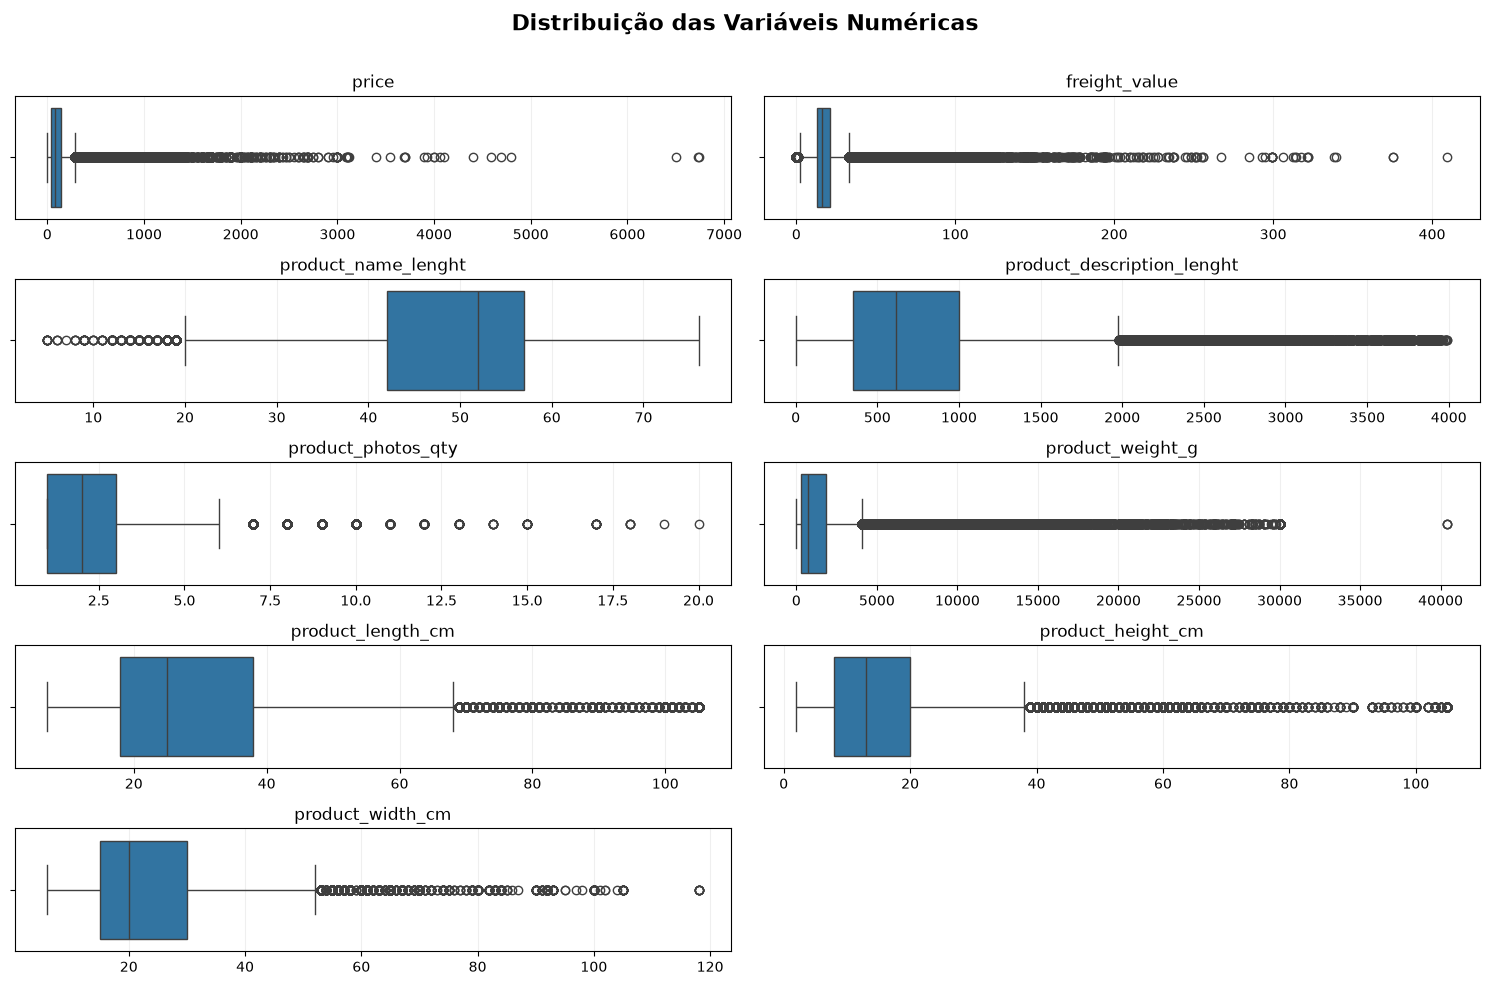

In [15]:
numeric_cols = [
    col for col, dtype in raw_olist_typed.schema.items()
    if dtype.is_numeric()
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15, 10)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        x=raw_olist_typed[col].to_numpy(),
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.grid(axis="x", alpha=0.2)

for ax in axes[len(numeric_cols):]:
    ax.remove()

fig.suptitle(
    "Distribuição das Variáveis Numéricas\n",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

TODO: necessário realizar a análise do boxplot de cada uma das variáveis...

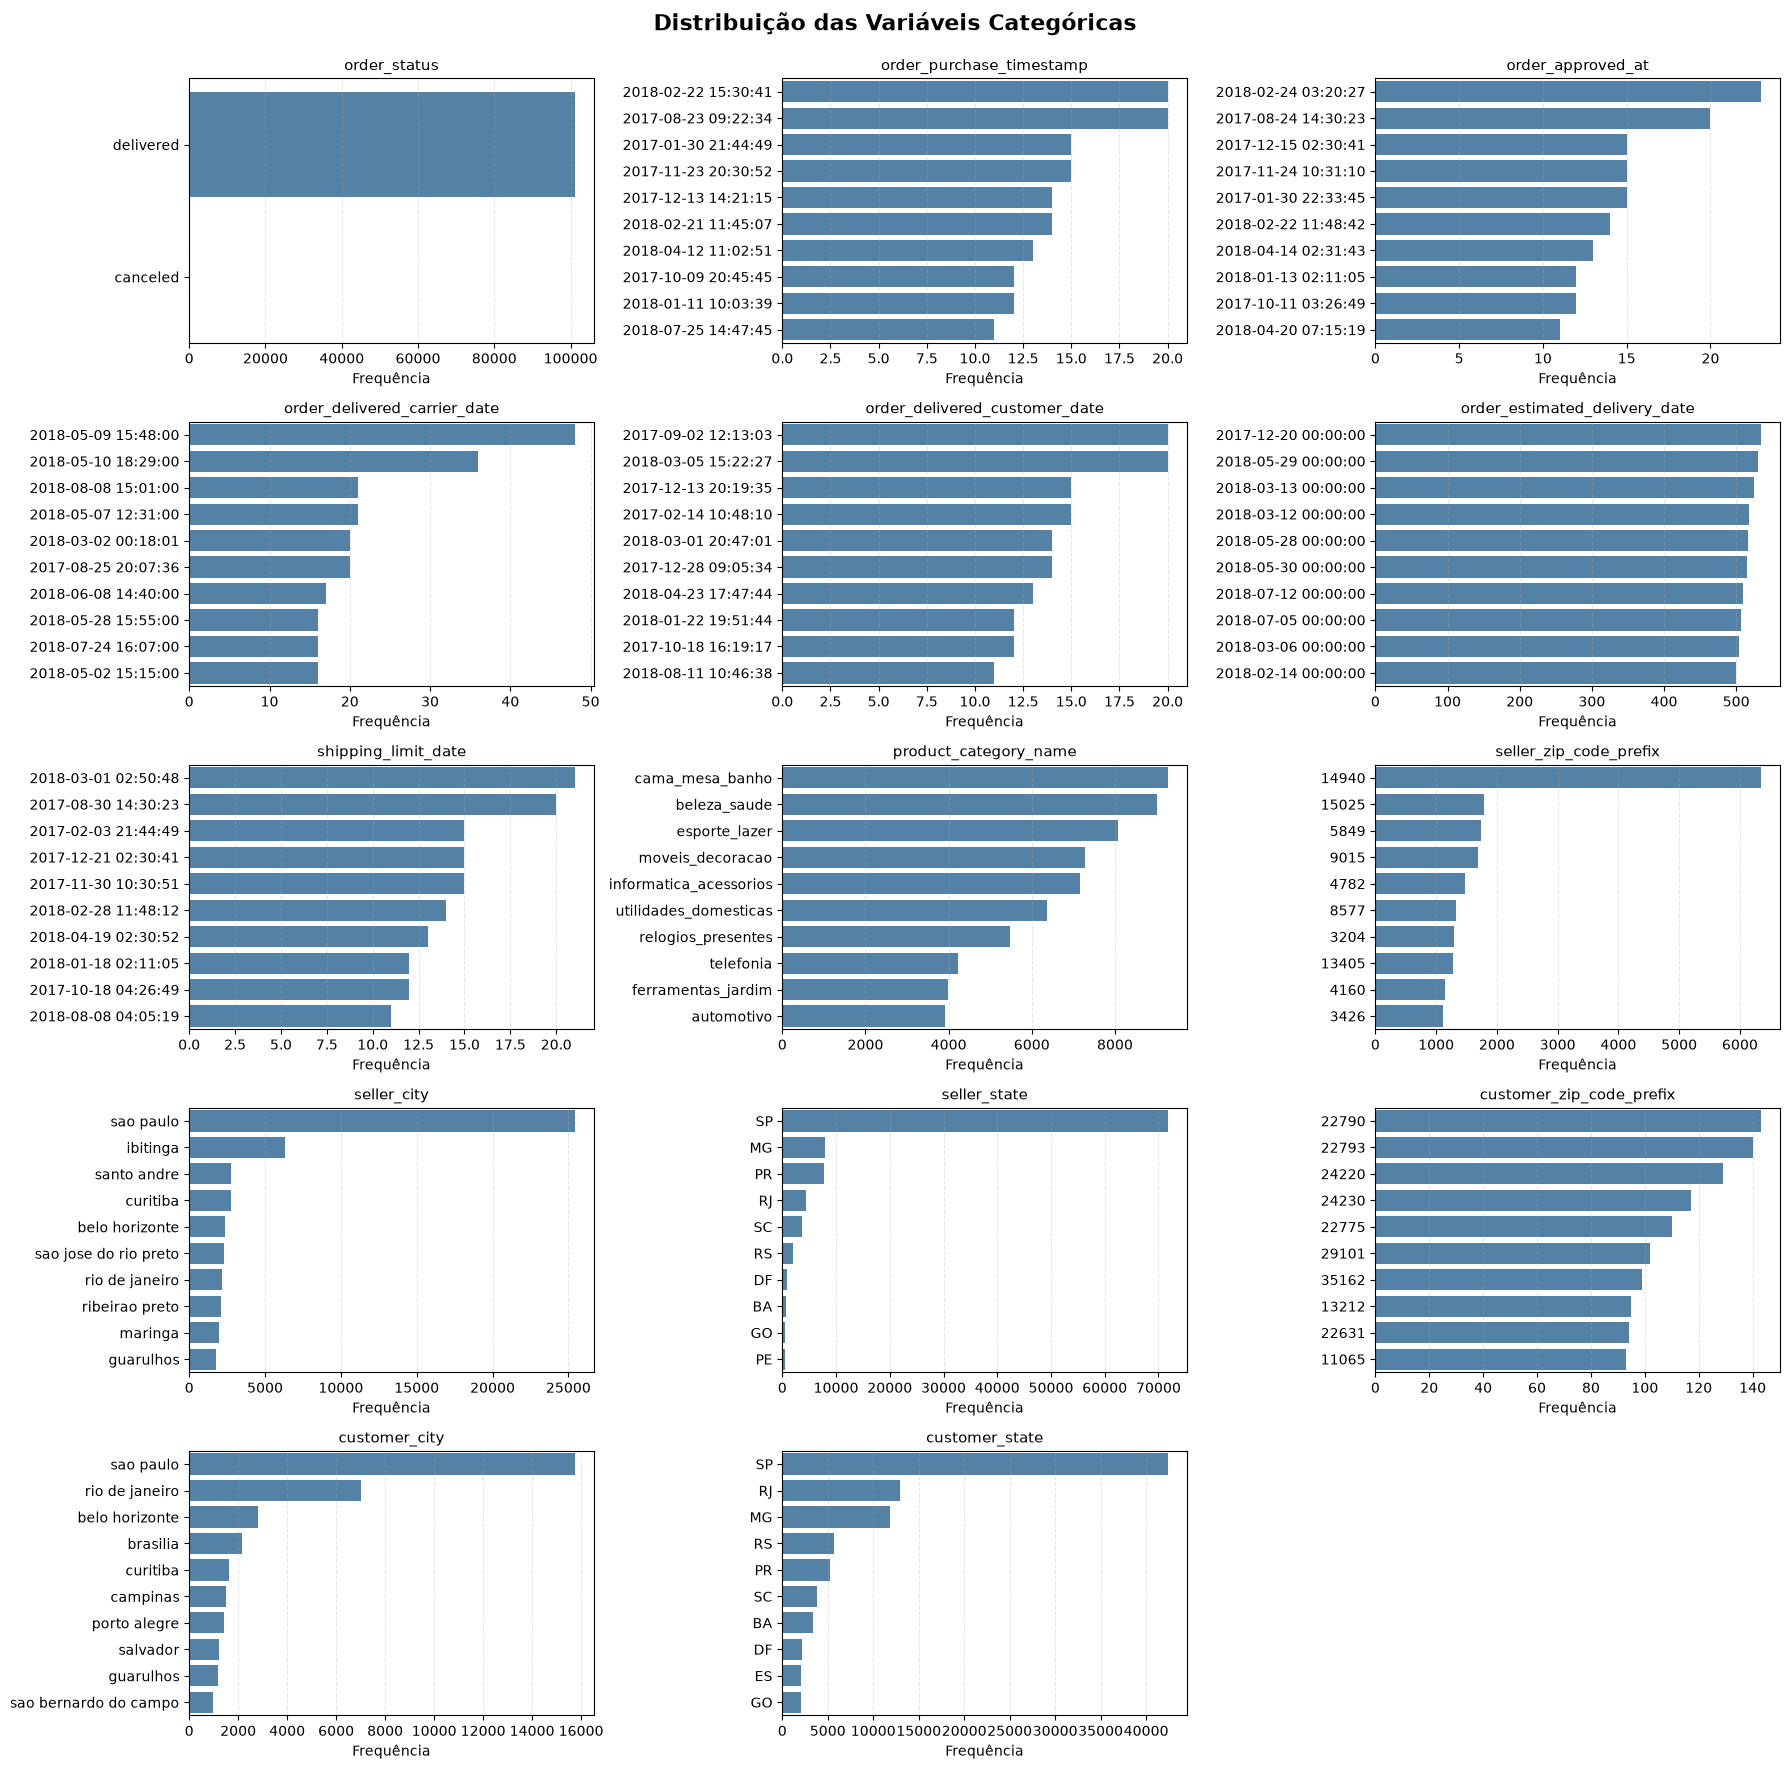

In [16]:
categorical_cols = [
    col for col, dtype in raw_olist_typed.schema.items()
    if dtype == pl.String
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(18, 18)
)

axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    counts = (
        raw_olist_typed
        .group_by(col)
        .len()
        .sort("len", descending=True)
        .head(10)
    )

    sns.barplot(
        data=counts.to_pandas(),
        x="len",
        y=col,
        ax=ax,
        color="steelblue"
    )

    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Frequência")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

for ax in axes[len(categorical_cols):]:
    ax.remove()

fig.suptitle(
    "Distribuição das Variáveis Categóricas\n",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

TODO: necessário realizar a análise de frequência de cada uma das variáveis e eventualmente criar novas variáveis (ex.: datas em formato "anomes" e região).

## Etapa 2 - Preparação dos dados

## Etapa 3 - Modelagem

## Etapa 4 - Avaliação dos Resultados